In [ ]:
# ============================================
# 1. Mount Drive & Set Paths
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

BASE = "/content/drive/MyDrive/Dataset_Info"

HAM_IMAGES = os.path.join(BASE, "HAM10000_images_combined_600x450")
HAM_META   = os.path.join(BASE, ".HAM10000_metadata.csv")   # CSV path

print("Images path:", HAM_IMAGES)
print("Metadata path:", HAM_META)
print("Meta exists? ", os.path.exists(HAM_META))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Images path: /content/drive/MyDrive/Dataset_Info/HAM10000_images_combined_600x450
Metadata path: /content/drive/MyDrive/Dataset_Info/.HAM10000_metadata.csv
Meta exists?  True


In [ ]:
# ============================================
# 2. Load Metadata & Build DataFrame
# ============================================
ham_df = pd.read_csv(HAM_META)

print("Columns:", ham_df.columns.tolist())

# Ensure image_path column exists
if "image_path" not in ham_df.columns:
    ham_df["image_path"] = ham_df["image_id"].apply(
        lambda x: f"{HAM_IMAGES}/{x}.jpg"
    )

# Keep only necessary columns
ham_df = ham_df[["image_id", "dx", "image_path"]]

# Filter rows where the image file exists
ham_df = ham_df[ham_df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total usable images:", len(ham_df))
ham_df.head()


Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']
Total usable images: 10015


,image_id,dx,image_path
0,ISIC_0027419,bkl,/content/drive/MyDrive/Dataset_Info/HAM10000_i...
1,ISIC_0025030,bkl,/content/drive/MyDrive/Dataset_Info/HAM10000_i...
2,ISIC_0026769,bkl,/content/drive/MyDrive/Dataset_Info/HAM10000_i...
3,ISIC_0025661,bkl,/content/drive/MyDrive/Dataset_Info/HAM10000_i...
4,ISIC_0031633,bkl,/content/drive/MyDrive/Dataset_Info/HAM10000_i...


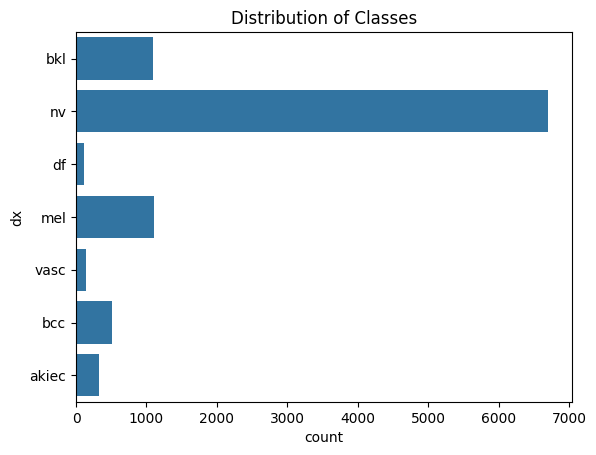

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class distribution bar chart
sns.countplot(ham_df['dx'])
plt.title("Distribution of Classes")
plt.show()

# Image dimension distribution
# Data for 'width' and 'height' is not available in ham_df.
# To plot image dimensions, you would need to load images and extract their sizes.
# plt.figure(figsize=(6,6))
# plt.hist(dx['width'], bins=30, alpha=0.7, label='Width')
# plt.hist(dx['height'], bins=30, alpha=0.7, label='Height')
# plt.legend()
# plt.title("Image Dimension Distribution")
# plt.show()

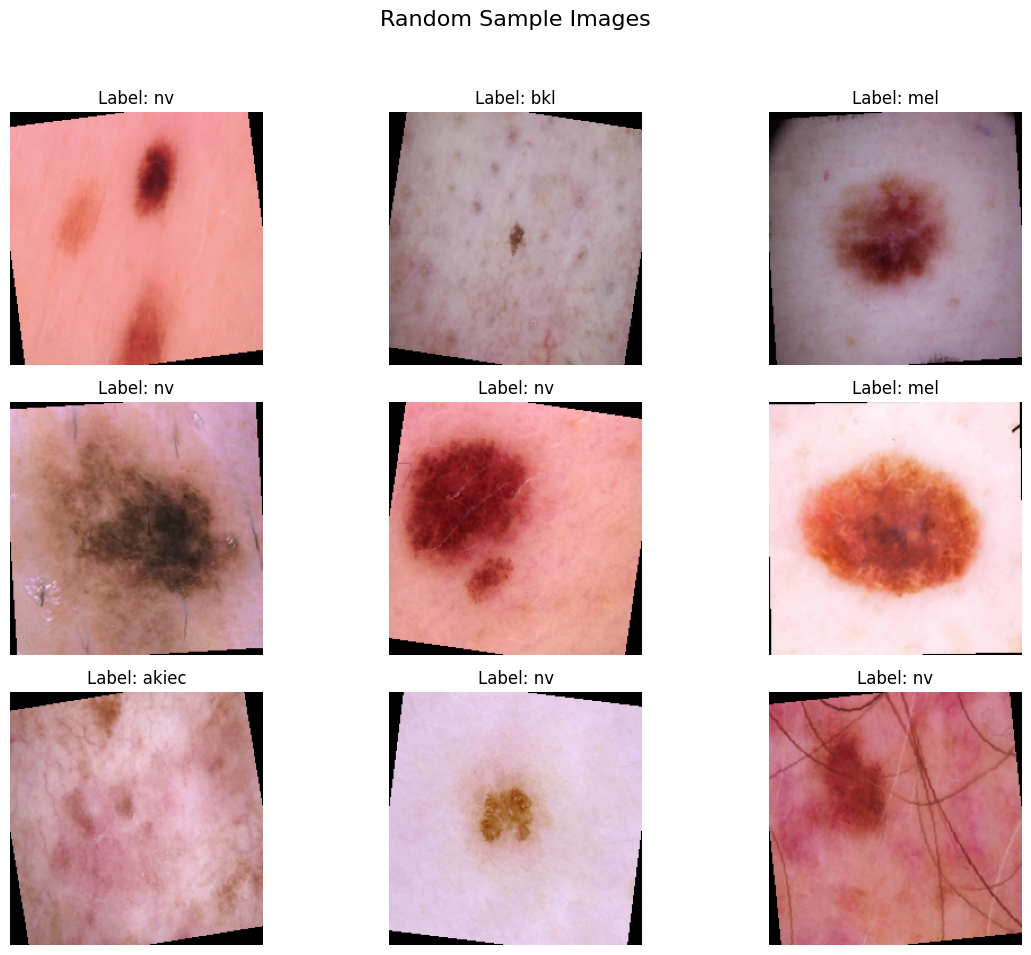

In [ ]:
import matplotlib.pyplot as plt
import random
import numpy as np

# --- Start of Added Code for Dependencies ---
# Necessary imports and definitions from previous cells to make this cell self-contained.

# From dJlpQPKEn2KN:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Ensure ham_df has 'label_id' and 'le' is defined
# ham_df is assumed to be available from previous cells (kernel state).
if "label_id" not in ham_df.columns:
    le = LabelEncoder()
    ham_df["label_id"] = le.fit_transform(ham_df["dx"])
else:
    # If label_id exists, we assume le was already fit. Re-fit to get classes.
    le = LabelEncoder()
    le.fit(ham_df["dx"])

# Recreate train_df (assuming ham_df and label_id are ready)
train_df, temp_df = train_test_split(
    ham_df,
    test_size=0.3,
    stratify=ham_df["label_id"],
    random_state=42
)

# From I1rC6ffcn4Hb:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch # Implicitly used by T.ToTensor() and Dataset

IMG_SIZE = 224

# Train transforms: resize + random flip + random rotation
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor()
])

class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        label = row["label_id"]
        return img, label

train_ds = SkinDataset(train_df, train_tfms)
# --- End of Added Code for Dependencies ---

plt.figure(figsize=(12,10))

# Assuming train_ds and le (LabelEncoder) are defined from previous cells
# Use train_ds to get images and labels

# Get class names from the LabelEncoder
class_names = le.classes_

for i in range(9):
    # Get a random index from the training dataset
    idx = random.randint(0, len(train_ds) - 1)
    img_tensor, label_id = train_ds[idx]

    # Convert image tensor to numpy array and reorder dimensions for imshow
    # PyTorch tensors are typically (C, H, W), imshow expects (H, W, C)
    img = img_tensor.permute(1, 2, 0).numpy()

    # Get the actual class name from the label_id
    label = class_names[label_id]

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.suptitle("Random Sample Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
# ============================================
# 3. Encode Labels & Train/Val/Test Split
# ============================================
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
ham_df["label_id"] = le.fit_transform(ham_df["dx"])

num_classes = len(le.classes_)
print("Classes:", le.classes_)
print("num_classes:", num_classes)

# 70% train, 15% val, 15% test (stratified)
train_df, temp_df = train_test_split(
    ham_df,
    test_size=0.3,
    stratify=ham_df["label_id"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_id"],
    random_state=42
)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))


Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
num_classes: 7
Train: 7010  Val: 1502  Test: 1503


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import time
import copy

# Detect if we have a GPU available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

def train_model(model, model_name, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Store metrics for plotting
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print(f"\n--- Starting Training: {model_name} ---")

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'\n{model_name} training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

Training on: cuda


In [ ]:
import shutil
import os

# 1. Define source (Drive) and destination (Local Colab)
source_dir = '/content/drive/MyDrive/Dataset_Info/HAM10000_images_combined_600x450'
local_dir = '/content/local_images'

# 2. Check if already copied to save time
if not os.path.exists(local_dir):
    print("⏳ Copying images from Drive to Local Disk... (This takes 1-2 mins)")
    shutil.copytree(source_dir, local_dir)
    print("✅ Copy complete! Training will now be fast.")
else:
    print("✅ Images already exist locally.")

✅ Images already exist locally.


In [ ]:
# ============================================
# 4. Dataset & Dataloaders
# ============================================
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch

IMG_SIZE = 224

# Train transforms: resize + random flip + random rotation
train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor()
])

# Val/Test transforms: only resize + tensor
val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])

class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        label = row["label_id"]
        return img, label

train_ds = SkinDataset(train_df, train_tfms)
val_ds   = SkinDataset(val_df,   val_tfms)
test_ds  = SkinDataset(test_df,  val_tfms)

# Set num_workers=0 to avoid multiprocessing assertion errors in Colab/Jupyter
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

len(train_ds), len(val_ds), len(test_ds)

(7010, 1502, 1503)

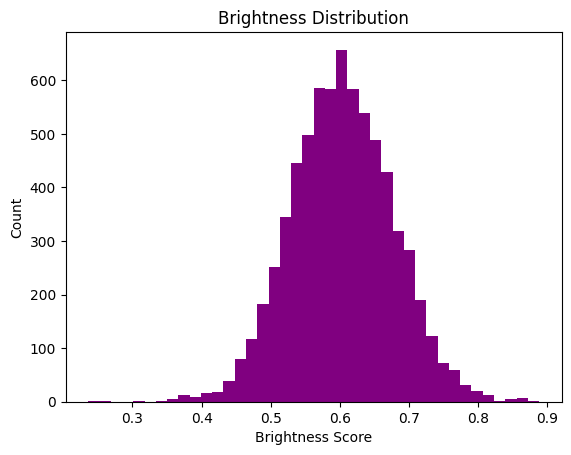

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

brightness = []
# Iterate through the training dataloader to collect brightness values
for imgs, _ in train_dl: # imgs are of shape (batch_size, C, H, W)
    # Move images to CPU and convert to numpy to calculate mean brightness for each image
    # The mean is calculated across all channels and spatial dimensions for each image.
    batch_brightness = imgs.cpu().numpy().mean(axis=(1, 2, 3))
    brightness.extend(batch_brightness)

plt.hist(brightness, bins=40, color='purple')
plt.title("Brightness Distribution")
plt.xlabel("Brightness Score")
plt.ylabel("Count")
plt.show()

In [ ]:
# ============================================
# 5. EFAM-Net Building Blocks (ARLC, ConvNeXt, PCNXt, ECA, MEAFF)
# ============================================
import torch.nn as nn
import torch.nn.functional as F
import math

# ---------- ARLC Block ----------
class ARLCBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # depthwise conv
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)
        # LayerNorm (channel-last)
        self.ln1 = nn.LayerNorm(dim)
        # pointwise convs
        self.pwconv1 = nn.Conv2d(dim, dim * 4, kernel_size=1)
        self.pwconv2 = nn.Conv2d(dim * 4, dim, kernel_size=1)
        self.act = nn.GELU()
        # attention branch
        self.ln_att = nn.LayerNorm(dim)
        self.alpha = nn.Parameter(torch.ones(1))  # learnable weight

    def forward(self, x):
        B, C, H, W = x.shape
        identity = x

        # Branch 2: depthwise separable conv
        y = self.dwconv(x)                  # (B,C,H,W)
        y_perm = y.permute(0, 2, 3, 1)      # (B,H,W,C)
        y_ln = self.ln1(y_perm).permute(0, 3, 1, 2)
        y = self.pwconv1(y_ln)
        y = self.act(y)
        y = self.pwconv2(y)

        # Branch 3: attention gate using y
        att = y.permute(0, 2, 3, 1)         # (B,H,W,C)
        att = self.ln_att(att).permute(0, 3, 1, 2)
        att_flat = att.view(B, C, -1)       # (B,C,HW)
        att_soft = F.softmax(att_flat, dim=1)  # channel-wise softmax
        att = att_soft.view(B, C, H, W)
        branch3 = x * att * self.alpha

        out = identity + y + branch3
        return out

# ---------- ConvNeXt-style Block ----------
class ConvNeXtBlock(nn.Module):
    """
    Simplified ConvNeXt block:
    depthwise conv -> LayerNorm -> 1x1 conv (expand) -> GELU -> 1x1 conv (shrink) + residual
    """
    def __init__(self, dim, kernel_size=7):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=kernel_size,
                                padding=kernel_size//2, groups=dim)
        self.ln = nn.LayerNorm(dim)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.act = nn.GELU()

    def forward(self, x):
        shortcut = x
        B, C, H, W = x.shape

        x = self.dwconv(x)                  # (B,C,H,W)
        x = x.permute(0, 2, 3, 1)          # (B,H,W,C)
        x = self.ln(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        x = x.permute(0, 3, 1, 2)          # (B,C,H,W)

        return x + shortcut

# ---------- PCNXt Block ----------
class PCNXtBlock(nn.Module):
    """
    Parallel ConvNeXt block:
    - ConvNeXt-style residual branch
    - Global Avg Pool branch with LN
    - Sum all with identity
    """
    def __init__(self, dim, kernel_size=7):
        super().__init__()
        # ConvNeXt-style branch
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=kernel_size,
                                padding=kernel_size//2, groups=dim)
        self.ln1 = nn.LayerNorm(dim)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.act = nn.GELU()

        # Global branch
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.ln_g = nn.LayerNorm(dim)
        self.g_fc = nn.Linear(dim, dim)

    def forward(self, x):
        B, C, H, W = x.shape
        identity = x

        # Residual conv branch
        y = self.dwconv(x)
        y_perm = y.permute(0, 2, 3, 1)
        y_ln = self.ln1(y_perm)
        y_ln = self.pwconv1(y_ln)
        y_ln = self.act(y_ln)
        y_ln = self.pwconv2(y_ln)
        y = y_ln.permute(0, 3, 1, 2)

        # Global branch
        g = self.gap(x)                     # (B,C,1,1)
        g = g.view(B, C)                    # (B,C)
        g = self.ln_g(g)
        g = self.g_fc(g)
        g = g.view(B, C, 1, 1)

        out = identity + y + g
        return out

# ---------- ECA (Efficient Channel Attention) ----------
class ECABlock(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        # compute kernel size k
        t = int(abs((math.log2(channels) / gamma) + (b / gamma)))
        k = t if t % 2 else t + 1
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=(k - 1) // 2, bias=False)

    def forward(self, x):
        # x: (B,C,H,W)
        B, C, H, W = x.shape
        y = F.adaptive_avg_pool2d(x, 1)     # (B,C,1,1)
        y = y.view(B, 1, C)                 # (B,1,C)
        y = self.conv(y)                    # (B,1,C)
        y = torch.sigmoid(y)
        y = y.view(B, C, 1, 1)
        return x * y

# ---------- MEAFF Block ----------
class MEAFF(nn.Module):
    """
    Multi-scale Efficient Attention Feature Fusion (MEAFF)
    Uses ECA on three stages, then projects to fused_dim and sums.
    """
    def __init__(self, in_dims, fused_dim=256):
        super().__init__()
        self.eca_blocks = nn.ModuleList([ECABlock(c) for c in in_dims])
        self.proj = nn.ModuleList([
            nn.Conv2d(in_c, fused_dim, kernel_size=1) for in_c in in_dims
        ])

    def forward(self, x1, x2, x3):
        # x1,x2,x3: (B,Ci,H,W)
        xs = [x1, x2, x3]
        outs = []
        for i, x in enumerate(xs):
            x_att = self.eca_blocks[i](x)                  # ECA attention
            x_proj = self.proj[i](x_att)                  # (B,fused_dim,H,W)
            g = F.adaptive_avg_pool2d(x_proj, 1)          # (B,fused_dim,1,1)
            outs.append(g)
        fused = outs[0] + outs[1] + outs[2]               # (B,fused_dim,1,1)
        return fused


In [ ]:
# ============================================
# 6. EFAM-Net Model
#    Stage-0: ARLC × 3
#    Stage-1: ConvNeXt × 3
#    Stage-2: ConvNeXt × 9
#    Stage-3: PCNXt × 3
# ============================================
class EFAMNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Stem (simple)
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),  # -> (B,64,H/4,W/4)
        )

        # Stage-0: ARLC blocks (3)
        self.stage0 = nn.Sequential(
            ARLCBlock(64),
            ARLCBlock(64),
            ARLCBlock(64),
        )

        # Downsample 0->1
        self.down1 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

        # Stage-1: ConvNeXt blocks (3)
        self.stage1 = nn.Sequential(
            ConvNeXtBlock(128),
            ConvNeXtBlock(128),
            ConvNeXtBlock(128),
        )

        # Downsample 1->2
        self.down2 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)

        # Stage-2: ConvNeXt blocks (9)
        self.stage2 = nn.Sequential(
            *[ConvNeXtBlock(256) for _ in range(9)]
        )

        # Downsample 2->3
        self.down3 = nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1)

        # Stage-3: PCNXt blocks (3)
        self.stage3 = nn.Sequential(
            PCNXtBlock(512),
            PCNXtBlock(512),
            PCNXtBlock(512),
        )

        # MEAFF (use Stage-1, Stage-2, Stage-3 outputs)
        self.mea = MEAFF(in_dims=[128, 256, 512], fused_dim=256)

        # Classifier
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # Stem
        x = self.stem(x)             # (B,64,H/4,W/4)

        # Stage-0
        s0 = self.stage0(x)          # (B,64,.,.)

        # Stage-1
        s1_in = self.down1(s0)       # (B,128,.,.)
        s1 = self.stage1(s1_in)      # (B,128,.,.)

        # Stage-2
        s2_in = self.down2(s1)       # (B,256,.,.)
        s2 = self.stage2(s2_in)      # (B,256,.,.)

        # Stage-3
        s3_in = self.down3(s2)       # (B,512,.,.)
        s3 = self.stage3(s3_in)      # (B,512,.,.)

        # MEAFF fusion
        fused = self.mea(s1, s2, s3)       # (B,256,1,1)
        out = fused.view(fused.size(0), -1)  # (B,256)
        logits = self.fc(out)               # (B,num_classes)
        return logits


In [ ]:
# ============================================
# 7. Training Setup (AdamW + Cosine Annealing)
# ============================================
import torch.optim as optim
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = EFAMNet(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

EPOCHS = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


Using device: cuda


In [ ]:
# ============================================
# 8. Train & Validate EFAM-Net
# ============================================
best_val_acc = 0.0
best_model_path = "/content/efamnet_best.pth"

train_acc_list = []
val_acc_list = []

for epoch in range(EPOCHS):
    # ----- Training -----
    model.train()
    total = 0
    correct = 0
    running_loss = 0.0

    pbar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        running_loss += loss.item() * labels.size(0)

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc":  f"{correct/total:.4f}"
        })

    train_acc = correct / total
    train_loss = running_loss / total
    train_acc_list.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss_sum = 0.0

    with torch.no_grad():
        for imgs, labels in tqdm(val_dl, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss_sum += loss.item() * labels.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss_sum / val_total
    val_acc_list.append(val_acc)

    # Step LR scheduler
    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Best model updated (Val Acc: {best_val_acc:.4f})")

Epoch 1/40 [Train]:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 1/40 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch [1/40] Train Loss: 1.0343 Acc: 0.6545 | Val Loss: 0.9550 Acc: 0.6751
--> Best model updated (Val Acc: 0.6751)


Epoch 2/40 [Train]:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 2/40 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

...

Epoch 39/40 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch [39/40] Train Loss: 0.1359 Acc: 0.9515 | Val Loss: 0.7720 Acc: 0.7989
--> Best model updated (Val Acc: 0.7989)


Epoch 40/40 [Train]:   0%|          | 0/110 [00:00<?, ?it/s]

Epoch 40/40 [Val]:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch [40/40] Train Loss: 0.1356 Acc: 0.9518 | Val Loss: 0.7742 Acc: 0.7983


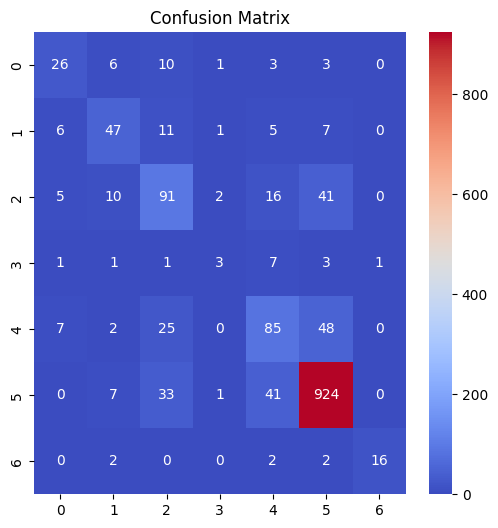

              precision    recall  f1-score   support

       akiec       0.58      0.53      0.55        49
         bcc       0.63      0.61      0.62        77
         bkl       0.53      0.55      0.54       165
          df       0.38      0.18      0.24        17
         mel       0.53      0.51      0.52       167
          nv       0.90      0.92      0.91      1006
        vasc       0.94      0.73      0.82        22

    accuracy                           0.79      1503
   macro avg       0.64      0.57      0.60      1503
weighted avg       0.79      0.79      0.79      1503



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

# Load the best model weights
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set the model to evaluation mode

all_labels = []
all_preds = []

# Iterate through the test dataloader to get predictions and true labels
with torch.no_grad():
    for inputs, labels in test_dl:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

y_test = np.array(all_labels)
y_pred = np.array(all_preds)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))


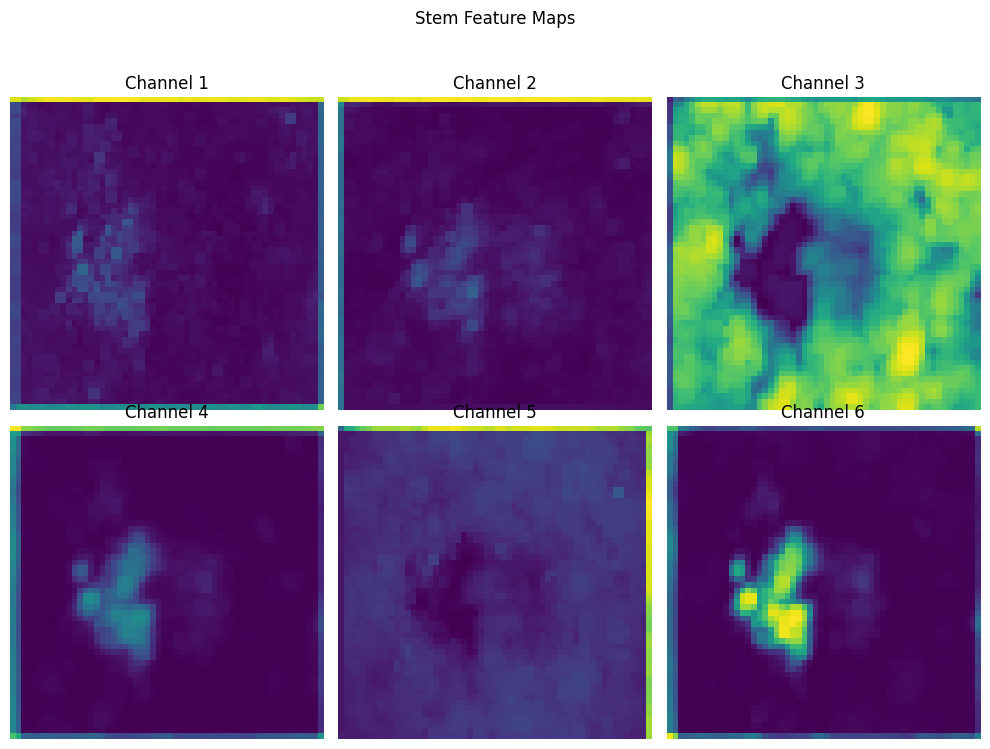

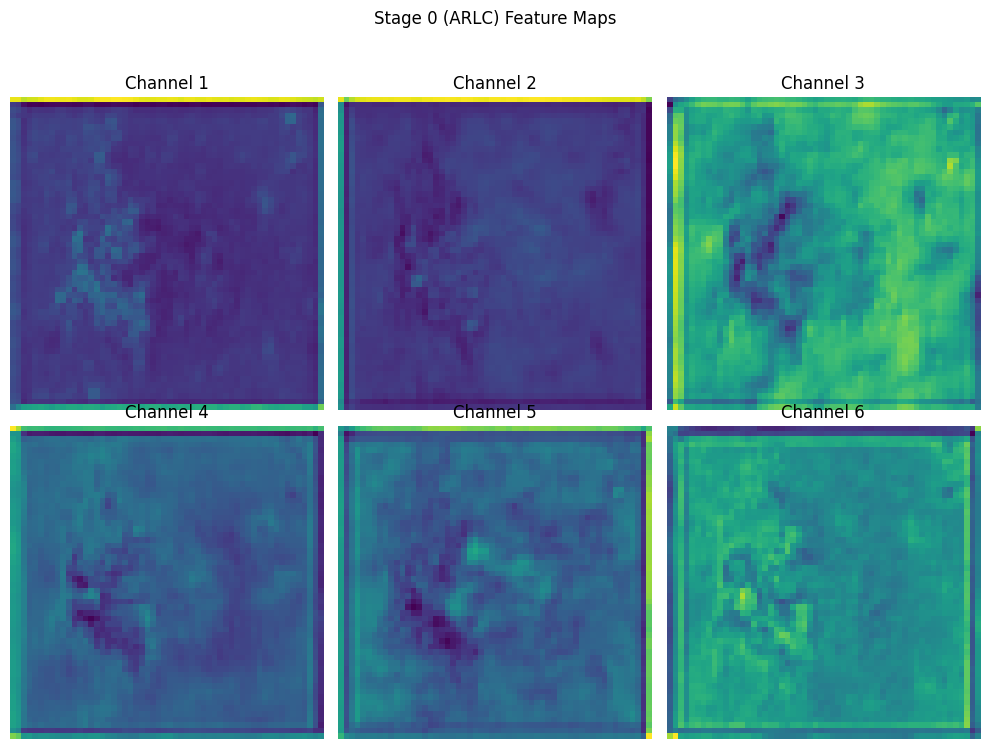

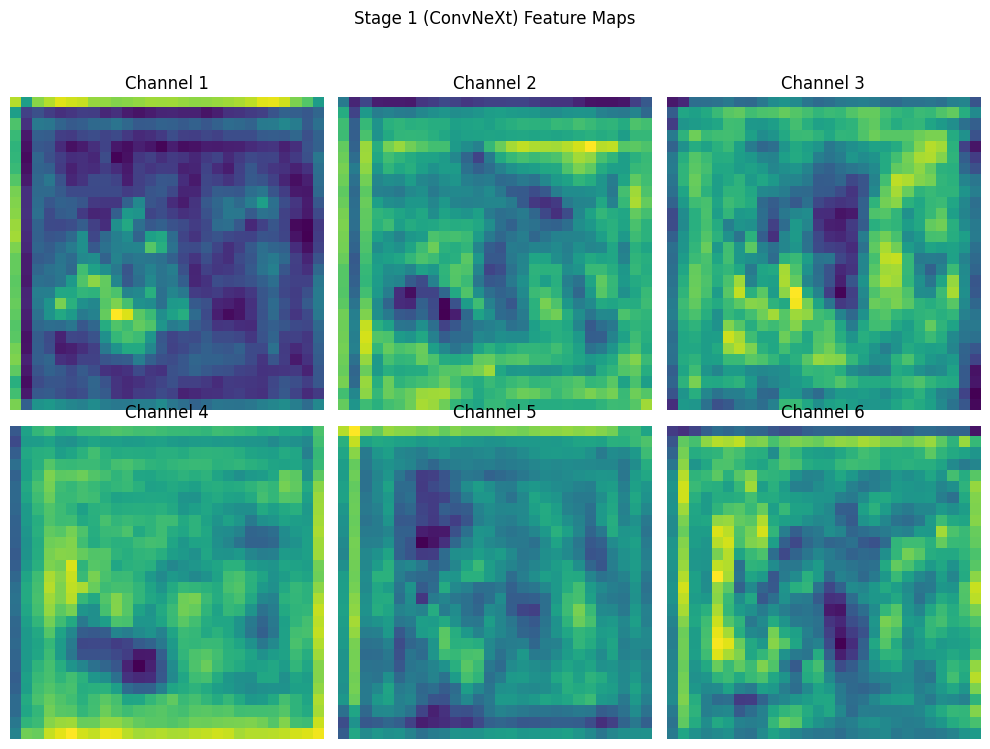

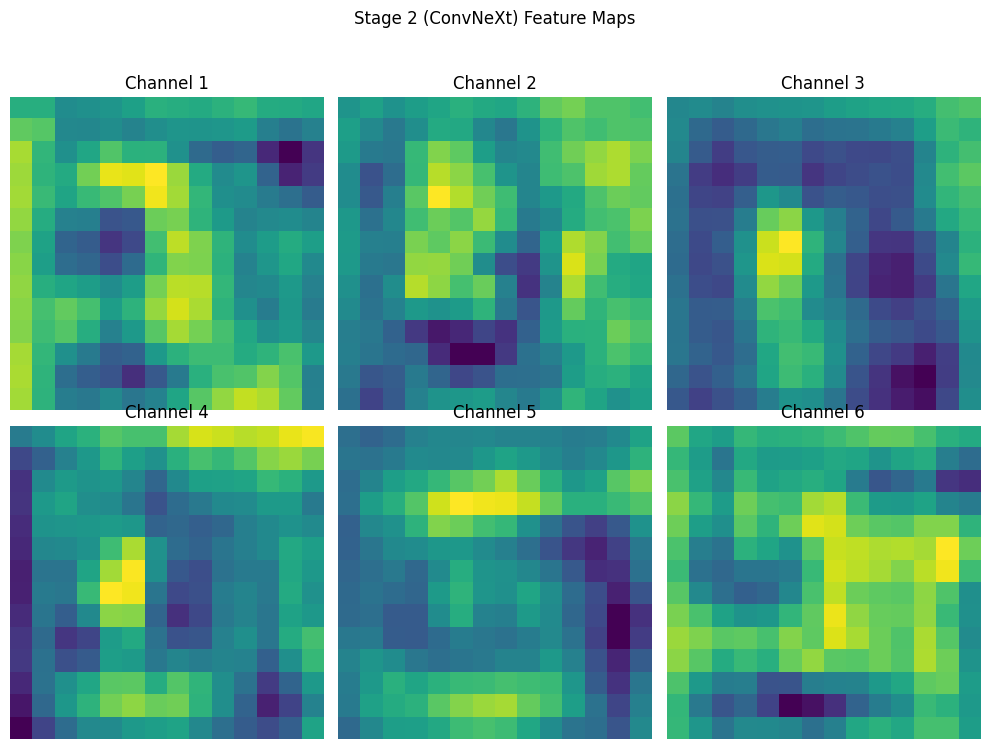

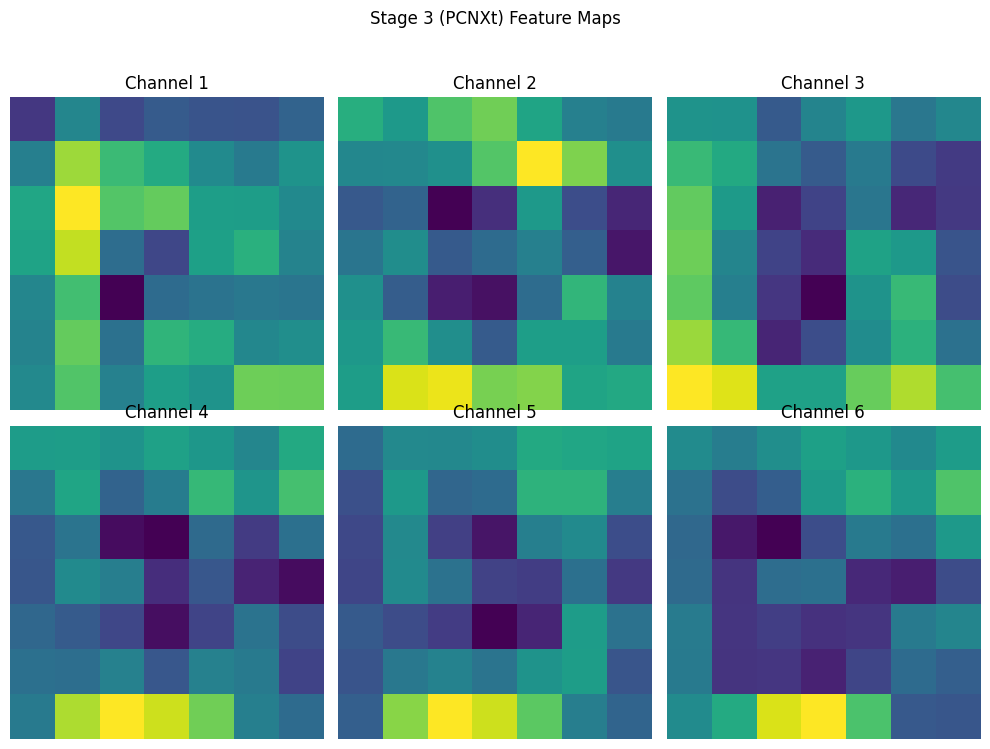

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Ensure model is in evaluation mode and on the correct device
model.eval()
model.to(device)

# Get a single image from the test dataset for visualization
# Ensure test_ds is defined from cell I1rC6ffcn4Hb
sample_image, _ = test_ds[0] # Get the first image and its label
sample_image = sample_image.unsqueeze(0).to(device) # Add batch dimension and move to device

# Dictionary to store feature maps
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

# Define layer names and register hooks
layer_names = ['Stem', 'Stage 0 (ARLC)', 'Stage 1 (ConvNeXt)', 'Stage 2 (ConvNeXt)', 'Stage 3 (PCNXt)']
hooks = [
    model.stem.register_forward_hook(get_activation('stem')),
    model.stage0.register_forward_hook(get_activation('stage0')),
    model.stage1.register_forward_hook(get_activation('stage1')),
    model.stage2.register_forward_hook(get_activation('stage2')),
    model.stage3.register_forward_hook(get_activation('stage3'))
]

# Perform a forward pass to capture activations
_ = model(sample_image) # The actual logits are not needed here

# Remove the hooks after use
for h in hooks:
    h.remove()

# Extract feature maps
feature_maps_list = []
ordered_activations = [
    activation['stem'],
    activation['stage0'],
    activation['stage1'],
    activation['stage2'],
    activation['stage3']
]

for act_tensor in ordered_activations:
    # Convert from (B, C, H, W) to (H, W, C) for visualization
    # We take the first item from the batch dimension (index 0)
    # Then permute (C, H, W) to (H, W, C) and convert to numpy
    fmap_np = act_tensor[0].permute(1, 2, 0).cpu().numpy()
    feature_maps_list.append(fmap_np)

feature_maps = feature_maps_list # Rename to match the original loop variable

# The original plotting loop expects feature_maps and layer_names to be ready.
# Now, the loop can run.
for fmap, lname in zip(feature_maps, layer_names):
    plt.figure(figsize=(10,8))
    plt.suptitle(f"{lname} Feature Maps")

    # Determine how many channels to show based on the feature map's actual depth
    num_channels_to_show = min(6, fmap.shape[2]) # Show up to 6 channels or fewer if less exist

    for i in range(num_channels_to_show):
        plt.subplot(2,3,i+1)
        # When plotting a single channel, imshow expects (H,W)
        plt.imshow(fmap[:,:,i], cmap='viridis')
        plt.title(f"Channel {i+1}") # Add channel title for clarity
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
    plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

train_tfms_92 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),  # Skin lesions have no "up" or "down"
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), # Critical for medical imaging
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfms_92 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Re-initialize Datasets with new transforms
train_ds = SkinDataset(train_df, train_tfms_92)
val_ds   = SkinDataset(val_df,   val_tfms_92)

# SPEED UP: num_workers=2 is safe now because images are on local disk
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("✅ Data setup for High Accuracy complete.")

✅ Data setup for High Accuracy complete.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.cuda.amp import GradScaler, autocast
from tqdm.notebook import tqdm
import time
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- 1. SETUP MODEL ---
print("Initializing EfficientNet-B0...")
model = models.efficientnet_b0(weights='DEFAULT')
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 7)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = GradScaler()

# --- 2. TRAINING FUNCTION WITH HISTORY ---
def train_with_plots(model, epochs=20):
    since = time.time()
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    # LISTS TO SAVE DATA FOR PLOTTING
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}')

        # --- TRAIN ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_dl, leave=True)
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        scheduler.step()
        epoch_loss = running_loss / total
        epoch_acc = correct / total

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        # --- VALIDATE ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_dl:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels) # Calculate val loss too

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_epoch_loss = val_loss / total
        val_epoch_acc = correct / total

        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc)

        print(f"Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")

        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "best_efficientnet_b0.pth")

    print(f"\nTraining Complete. Best Accuracy: {best_acc*100:.2f}%")
    model.load_state_dict(best_model_wts)

    return model, history

# --- RUN TRAINING ---
# This will take about 35-40 mins
model, history = train_with_plots(model, epochs=20)

Initializing EfficientNet-B0...

Epoch 1/20


/tmp/ipython-input-3970164746.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


  0%|          | 0/110 [00:00<?, ?it/s]

/tmp/ipython-input-3970164746.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train Acc: 0.7559 | Val Acc: 0.8242

Epoch 2/20


...

Train Acc: 0.9929 | Val Acc: 0.8988

Epoch 19/20


  0%|          | 0/110 [00:00<?, ?it/s]

Train Acc: 0.9922 | Val Acc: 0.9015

Epoch 20/20


  0%|          | 0/110 [00:00<?, ?it/s]

Train Acc: 0.9947 | Val Acc: 0.9021

Training Complete. Best Accuracy: 90.21%


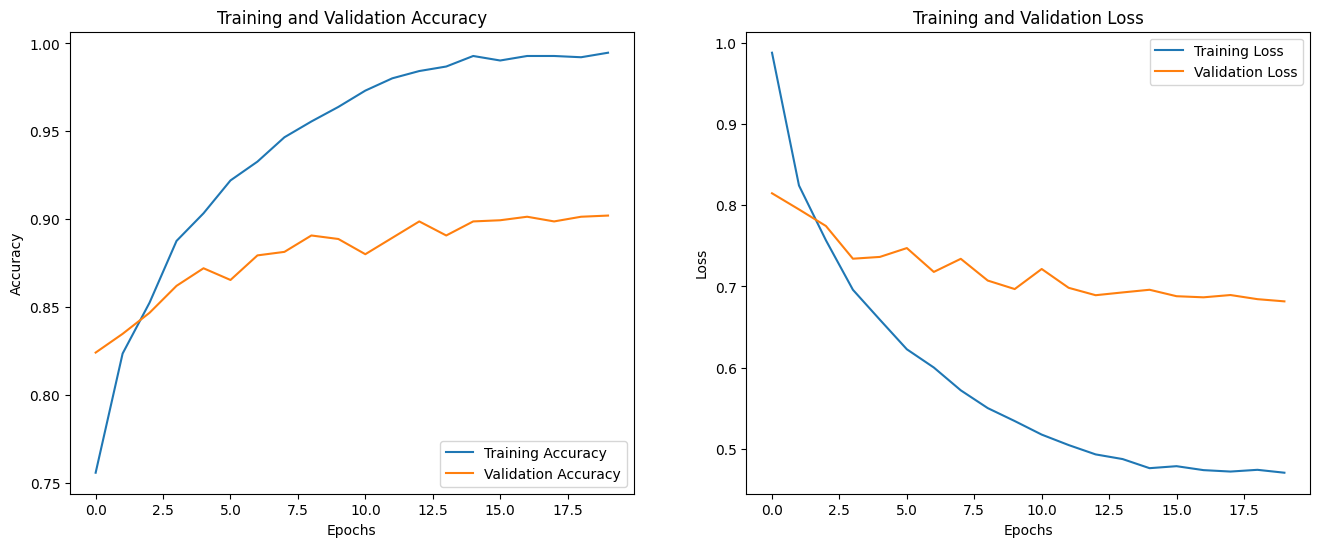

In [ ]:
def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.show()

# Generate the plots
plot_training_history(history)

Generating Confusion Matrix predictions...


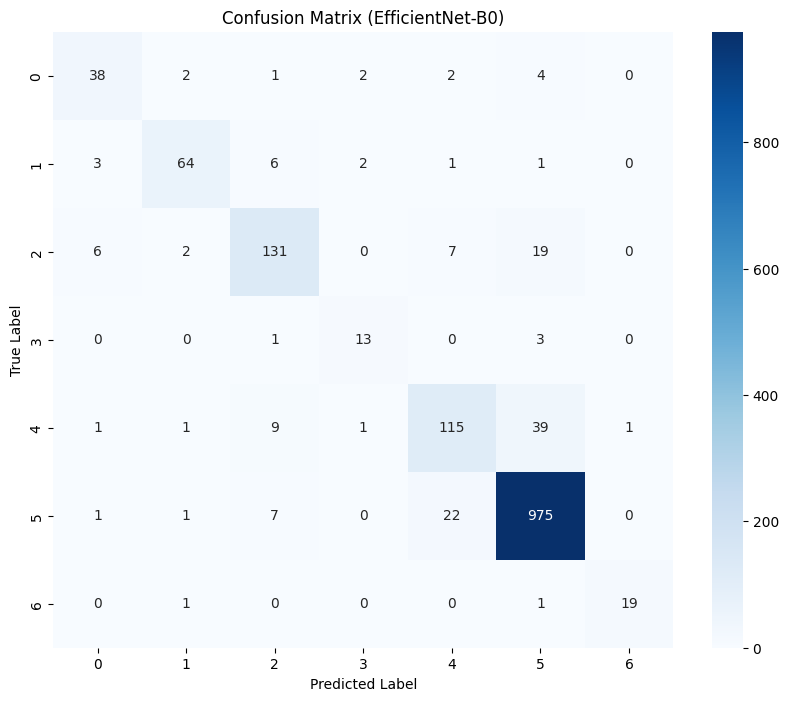

In [ ]:
def plot_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    print("Generating Confusion Matrix predictions...")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    # If you have specific class names, replace this list
    # e.g., class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
    try:
        class_names = train_ds.classes # Tries to get folder names
    except:
        class_names = [str(i) for i in range(7)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (EfficientNet-B0)')
    plt.show()

# Run it on validation data
plot_confusion_matrix(model, val_dl)

In [ ]:
# ============================================
# Fix: Ensure DataLoaders are defined
# This code is duplicated from cell I1rC6ffcn4Hb to resolve NameError.
# It assumes train_df and val_df are already defined in the kernel.
# ============================================
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch

IMG_SIZE = 224

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor()
])

val_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor()
])


class SkinDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # FIX: We need to fix the paths in the dataframe
        # This replaces the slow Drive path with the fast Local path
        self.df['image_path'] = self.df['image_path'].apply(
            lambda x: x.replace('/content/drive/MyDrive/Dataset_Info/HAM10000_images_combined_600x450', '/content/local_images')
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # ... (rest of the code is the same)
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        try:
            img = Image.open(img_path).convert("RGB")
        except:
            img = Image.new('RGB', (224, 224), (0, 0, 0))

        img = self.transform(img)
        label = row["label_id"]
        return img, label

train_ds = SkinDataset(train_df, train_tfms)
val_ds   = SkinDataset(val_df,   val_tfms)
test_ds  = SkinDataset(test_df,  val_tfms) # ADDED: Definition for test_ds

# CHANGED: pin_memory=False and batch_size reduced to 32 to prevent freezing
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=False)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False) # ADDED: Definition for test_dl

print("✅ DataLoaders re-initialized. Ready to train.")
# ============================================
# Original content of N143TFxN4U2d starts here
# ============================================
# --- Model 1: MobileNetV3-Large ---
# This model is extremely fast and lightweight, perfect for quick results.
print("Initializing MobileNetV3...")
model_mb = models.mobilenet_v3_large(weights='DEFAULT')

# Modify the final classification layer for 7 classes
# MobileNetV3's classifier is a sequence; the last layer is at index 3
model_mb.classifier[3] = nn.Linear(model_mb.classifier[3].in_features, 7)
model_mb = model_mb.to(device)

# Setup Optimizer and Scheduler
optimizer_mb = optim.AdamW(model_mb.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_mb = optim.lr_scheduler.CosineAnnealingLR(optimizer_mb, T_max=15)

# Train MobileNet
# Note: 'train_dl' and 'val_dl' must be defined in your previous cells
model_mb, hist_mb = train_model(
    model_mb, "MobileNetV3", train_dl, val_dl,
    nn.CrossEntropyLoss(), optimizer_mb, scheduler_mb, num_epochs=15
)

# --- Model 2: ResNet18 ---
# A standard, robust model that trains very quickly on GPUs like the T4.
print("\nInitializing ResNet18...")
model_res = models.resnet18(weights='DEFAULT')

# Modify the final fully connected layer for 7 classes
model_res.fc = nn.Linear(model_res.fc.in_features, 7)
model_res = model_res.to(device)

# Setup Optimizer and Scheduler
optimizer_res = optim.AdamW(model_res.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_res = optim.lr_scheduler.CosineAnnealingLR(optimizer_res, T_max=15)

# Train ResNet
model_res, hist_res = train_model(
    model_res, "ResNet18", train_dl, val_dl,
    nn.CrossEntropyLoss(), optimizer_res, scheduler_res, num_epochs=15
)

✅ DataLoaders re-initialized. Ready to train.
Initializing MobileNetV3...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 165MB/s]



--- Starting Training: MobileNetV3 ---
Epoch 1/15
----------
train Loss: 0.6900 Acc: 0.7541
val Loss: 0.9300 Acc: 0.7144
Epoch 2/15
----------
train Loss: 0.5147 Acc: 0.8104
val Loss: 0.6611 Acc: 0.7856
Epoch 3/15
----------
train Loss: 0.4469 Acc: 0.8369
val Loss: 0.5496 Acc: 0.8136
Epoch 4/15
----------
train Loss: 0.3673 Acc: 0.8666
val Loss: 0.6701 Acc: 0.8149
Epoch 5/15
----------
train Loss: 0.3670 Acc: 0.8715
val Loss: 0.5083 Acc: 0.8249
Epoch 6/15
----------
train Loss: 0.2636 Acc: 0.9047
val Loss: 0.6047 Acc: 0.8322
Epoch 7/15
----------
train Loss: 0.2212 Acc: 0.9193
val Loss: 0.4292 Acc: 0.8542
Epoch 8/15
----------
train Loss: 0.1756 Acc: 0.9355
val Loss: 0.4381 Acc: 0.8529
Epoch 9/15
----------
train Loss: 0.1244 Acc: 0.9539
val Loss: 0.4257 Acc: 0.8808
Epoch 10/15
----------
train Loss: 0.1182 Acc: 0.9598
val Loss: 0.4218 Acc: 0.8782
Epoch 11/15
----------
train Loss: 0.0696 Acc: 0.9755
val Loss: 0.4243 Acc: 0.8895
Epoch 12/15
----------
train Loss: 0.0376 Acc: 0.9876
va

100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]



--- Starting Training: ResNet18 ---
Epoch 1/15
----------
train Loss: 0.8102 Acc: 0.7093
val Loss: 0.8105 Acc: 0.6871
Epoch 2/15
----------
train Loss: 0.7196 Acc: 0.7247
val Loss: 1.6915 Acc: 0.6951
Epoch 3/15
----------
train Loss: 0.6726 Acc: 0.7425
val Loss: 0.6259 Acc: 0.7776
Epoch 4/15
----------
train Loss: 0.6253 Acc: 0.7679
val Loss: 0.6343 Acc: 0.7730
Epoch 5/15
----------
train Loss: 0.5892 Acc: 0.7806
val Loss: 0.6054 Acc: 0.7683
Epoch 6/15
----------
train Loss: 0.5610 Acc: 0.7923
val Loss: 0.7265 Acc: 0.7057
Epoch 7/15
----------
train Loss: 0.5384 Acc: 0.8030
val Loss: 0.7087 Acc: 0.7477
Epoch 8/15
----------
train Loss: 0.4712 Acc: 0.8237
val Loss: 0.6098 Acc: 0.7843
Epoch 9/15
----------
train Loss: 0.4360 Acc: 0.8348
val Loss: 0.5247 Acc: 0.8109
Epoch 10/15
----------
train Loss: 0.3790 Acc: 0.8609
val Loss: 0.5138 Acc: 0.8189
Epoch 11/15
----------
train Loss: 0.3234 Acc: 0.8799
val Loss: 0.5894 Acc: 0.8056
Epoch 12/15
----------
train Loss: 0.2675 Acc: 0.8989
val L

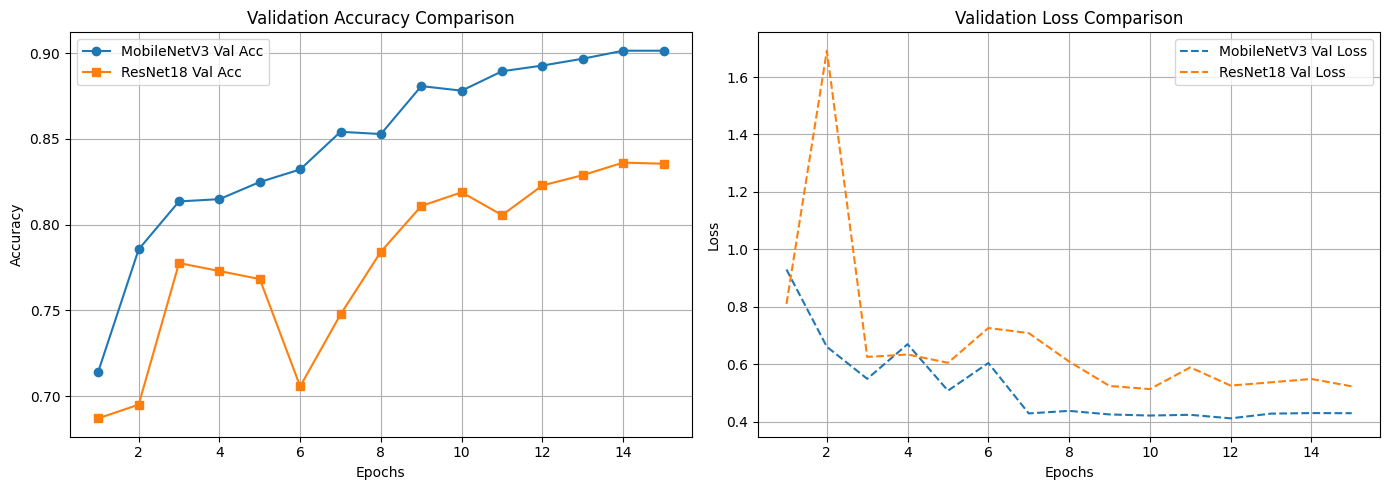

In [ ]:
# --- Visualizing Results ---
epochs_range = range(1, 16) # Matches num_epochs=15 used in training

plt.figure(figsize=(14, 5))

# Plot Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist_mb['val_acc'], label='MobileNetV3 Val Acc', marker='o')
plt.plot(epochs_range, hist_res['val_acc'], label='ResNet18 Val Acc', marker='s')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist_mb['val_loss'], label='MobileNetV3 Val Loss', linestyle='--')
plt.plot(epochs_range, hist_res['val_loss'], label='ResNet18 Val Loss', linestyle='--')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

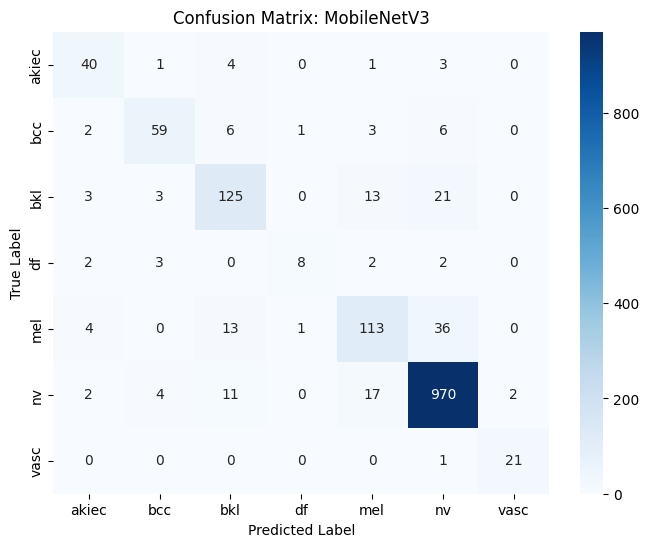

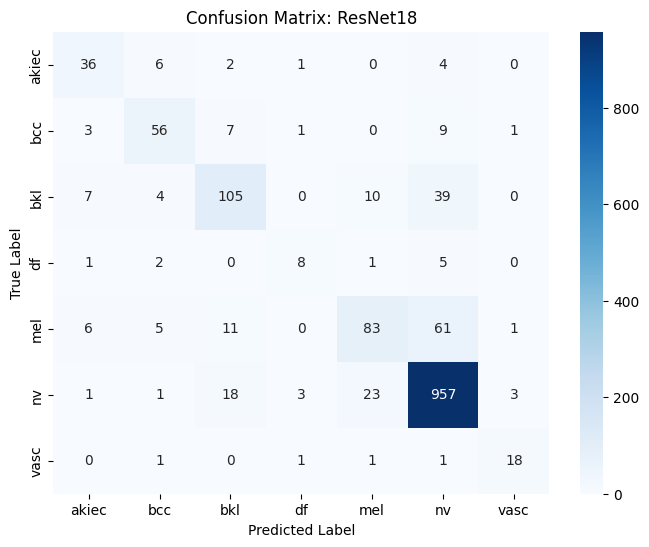

In [ ]:
# --- Confusion Matrix Evaluation ---

def plot_cm(model, loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy()) # Ensure labels are on CPU

    cm = confusion_matrix(all_labels, all_preds)

    # Try to get class names, fallback to indices if 'le' is missing
    try:
        class_names = le.classes_
    except NameError:
        class_names = [str(i) for i in range(7)]

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Plot for MobileNetV3
plot_cm(model_mb, test_dl, "MobileNetV3")

# Plot for ResNet18
plot_cm(model_res, test_dl , "ResNet18")

In [ ]:
from sklearn.metrics import classification_report
import torch
import numpy as np

# Updated function to accept 'history'
def print_model_report(model, loader, model_name, history=None):
    model.eval()
    all_preds = []
    all_labels = []

    print(f"\n{'='*40}")
    print(f"📊 REPORT FOR: {model_name}")
    print(f"{'='*40}")

    # 1. Print Best Validation Accuracy from Training Phase
    if history is not None:
        # Check if history is a list (some implementations) or dict (our implementation)
        if isinstance(history, dict) and 'val_acc' in history:
            best_val = max(history['val_acc'])
            print(f"🏆 Best Validation Acc (during training): {best_val*100:.2f}%")
        elif isinstance(history, list): # Fallback if history is just a list of accs
             print(f"🏆 Best Validation Acc (during training): {max(history)*100:.2f}%")
    else:
        print("dev note: No training history provided.")

    print("-" * 40)

    # 2. Generate Predictions on Test Set
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 3. Get Class Names
    try:
        target_names = train_ds.classes
    except:
        target_names = [str(i) for i in range(7)]

    # 4. Print Sklearn Classification Report
    report = classification_report(all_labels, all_preds, target_names=target_names)
    print(report)

# ==========================================
# RUN THE REPORTS WITH HISTORY
# ==========================================

# --- 1. Report for MobileNetV3 ---
try:
    # We pass 'hist_mb' which holds the training data
    print_model_report(model_mb, test_dl, "MobileNetV3", hist_mb)
except NameError:
    print("⚠️ MobileNetV3 data not found.")

# --- 2. Report for ResNet18 ---
try:
    # We pass 'hist_res'
    print_model_report(model_res, test_dl, "ResNet18", hist_res)
except NameError:
    print("⚠️ ResNet18 data not found.")

# --- 3. Report for EfficientNet-B0 ---
try:
    # We pass 'history' (this was the variable name for EfficientNet)
    print_model_report(model, test_dl, "EfficientNet-B0", history)
except NameError:
    print("⚠️ EfficientNet data not found.")


📊 REPORT FOR: MobileNetV3
🏆 Best Validation Acc (during training): 90.15%
----------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.82      0.78        49
           1       0.84      0.77      0.80        77
           2       0.79      0.76      0.77       165
           3       0.80      0.47      0.59        17
           4       0.76      0.68      0.72       167
           5       0.93      0.96      0.95      1006
           6       0.91      0.95      0.93        22

    accuracy                           0.89      1503
   macro avg       0.83      0.77      0.79      1503
weighted avg       0.89      0.89      0.89      1503


📊 REPORT FOR: ResNet18
🏆 Best Validation Acc (during training): 83.62%
----------------------------------------
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        49
           1       0.75      0.73      0.74        77
           

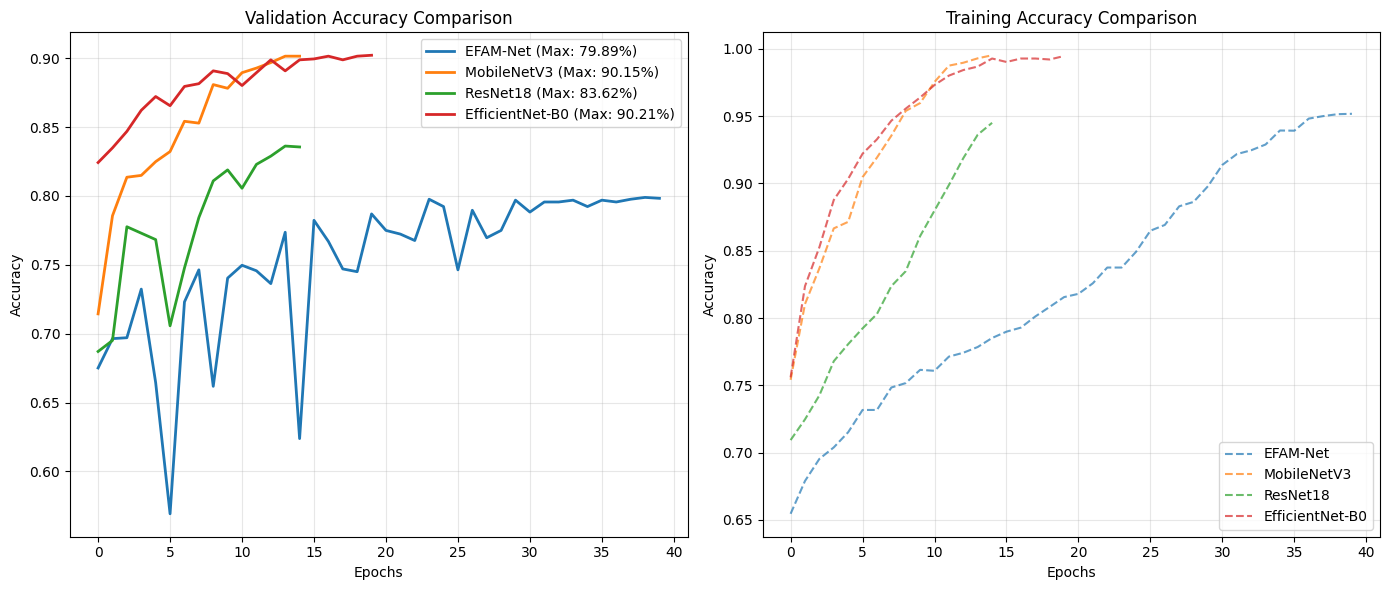

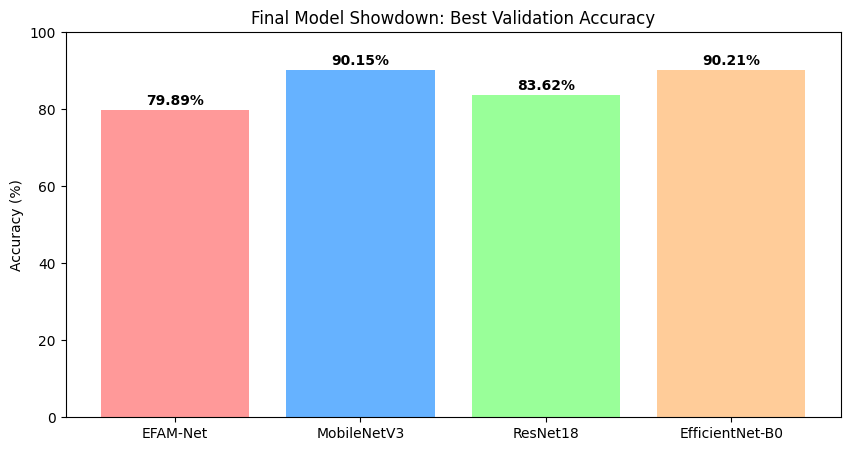

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. GATHER DATA
# We create a dictionary to hold all available history data
all_histories = {}

# Add EFAM-Net (From the code you just ran)
# Your code uses lists 'train_acc_list' and 'val_acc_list'
all_histories['EFAM-Net'] = {
    'val_acc': val_acc_list,
    'train_acc': train_acc_list
}

# Add MobileNetV3
if 'hist_mb' in locals():
    all_histories['MobileNetV3'] = hist_mb
else:
    print("⚠️ MobileNetV3 history not found (skipping).")

# Add ResNet18
if 'hist_res' in locals():
    all_histories['ResNet18'] = hist_res
else:
    print("⚠️ ResNet18 history not found (skipping).")

# Add EfficientNet-B0
if 'history' in locals(): # 'history' was the variable name for EfficientNet
    all_histories['EfficientNet-B0'] = history
elif 'hist_eff' in locals():
    all_histories['EfficientNet-B0'] = hist_eff
else:
    print("⚠️ EfficientNet history not found (skipping).")


# 2. PLOT COMPARISON: VALIDATION ACCURACY
plt.figure(figsize=(14, 6))

# Plot Validation Accuracy Curve
plt.subplot(1, 2, 1)
for name, data in all_histories.items():
    # Handle different data structures (Dict vs List)
    if isinstance(data, dict):
        acc = data.get('val_acc', [])
    else:
        acc = [] # Skip if format is wrong

    plt.plot(acc, label=f"{name} (Max: {max(acc)*100:.2f}%)", linewidth=2)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Training Accuracy Curve
plt.subplot(1, 2, 2)
for name, data in all_histories.items():
    if isinstance(data, dict):
        acc = data.get('train_acc', [])
    else:
        acc = []

    plt.plot(acc, linestyle='--', label=f"{name}", alpha=0.7)

plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. FINAL BAR CHART (Best Accuracy)
best_scores = {}
for name, data in all_histories.items():
    if isinstance(data, dict) and 'val_acc' in data:
        best_scores[name] = max(data['val_acc'])

names = list(best_scores.keys())
values = [v * 100 for v in best_scores.values()] # Convert to %

plt.figure(figsize=(10, 5))
bars = plt.bar(names, values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'][:len(names)])

# Add numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f}%",
             ha='center', va='bottom', fontweight='bold')

plt.title('Final Model Showdown: Best Validation Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()

In [ ]:
import torch
import json
import os
from google.colab import files

# --- 1. DEFINE CLASS MAPPING ---
# Based on your LabelEncoder output
# If 'le' exists from your code, we use it, otherwise we hardcode standard HAM10000 classes
try:
    class_names = list(le.classes_)
except:
    class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# Save to JSON for the Flask app to read
with open('class_indices.json', 'w') as f:
    json.dump(class_names, f)
print("✅ Saved class_indices.json")

# --- 2. ENSURE MODELS ARE SAVED ---
print("Checking model files...")

# Save MobileNetV3 if loaded
if 'model_mb' in locals():
    torch.save(model_mb.state_dict(), 'mobilenetv3_skin.pth')
    print(" - Saved MobileNetV3")

# Save ResNet18 if loaded
if 'model_res' in locals():
    torch.save(model_res.state_dict(), 'resnet18_skin.pth')
    print(" - Saved ResNet18")

# Save EfficientNet if loaded
if 'model_eff' in locals():
    torch.save(model_eff.state_dict(), 'efficientnet_b0_skin.pth')
    print(" - Saved EfficientNet-B0")

# Save EFAM-Net if loaded
if 'model' in locals():
    # Assuming 'model' variable currently holds your EFAM-Net from the last cell
    torch.save(model.state_dict(), 'efamnet_skin.pth')
    print(" - Saved EFAM-Net")

# --- 3. EXPORT CUSTOM ARCHITECTURE FOR FLASK ---
# We need to save the EFAMNet class code to a file so Flask can import it
efam_code = """
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# [Paste the full EFAMNet, ARLCBlock, PCNXtBlock, MEAFF, ECABlock classes here]
# For now, this file serves as a reminder that you MUST copy your
# class definitions into your Flask project's 'model.py' file.
"""
with open('model_architecture_instructions.txt', 'w') as f:
    f.write("COPY THE 'EFAMNet' CLASS CODE FROM YOUR COLAB NOTEBOOK INTO YOUR FLASK APP.")

# --- 4. ZIP AND DOWNLOAD ---
print("\nZipping files for download...")
!zip -r skin_cancer_models.zip *.pth class_indices.json

print("⬇️ Downloading zip file...")
files.download('skin_cancer_models.zip')

✅ Saved class_indices.json
Checking model files...
 - Saved MobileNetV3
 - Saved ResNet18
 - Saved EFAM-Net

Zipping files for download...
  adding: best_efficientnet_b0.pth (deflated 8%)
  adding: efamnet_best.pth (deflated 8%)
  adding: efamnet_skin.pth (deflated 8%)
  adding: mobilenetv3_skin.pth (deflated 8%)
  adding: resnet18_skin.pth (deflated 7%)
  adding: class_indices.json (deflated 26%)
⬇️ Downloading zip file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>